# **Preprocessing Data**

## Set up

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from palmerpenguins import load_penguins_raw

In [2]:
penguins = load_penguins_raw()

penguins.head()

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,2007-11-11,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,2007-11-11,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,2007-11-16,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,2007-11-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,2007-11-16,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN


## Inspect data quality check

In [3]:
# Check dataset
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            344 non-null    str    
 1   Sample Number        344 non-null    int64  
 2   Species              344 non-null    str    
 3   Region               344 non-null    str    
 4   Island               344 non-null    str    
 5   Stage                344 non-null    str    
 6   Individual ID        344 non-null    str    
 7   Clutch Completion    344 non-null    str    
 8   Date Egg             344 non-null    str    
 9   Culmen Length (mm)   342 non-null    float64
 10  Culmen Depth (mm)    342 non-null    float64
 11  Flipper Length (mm)  342 non-null    float64
 12  Body Mass (g)        342 non-null    float64
 13  Sex                  333 non-null    str    
 14  Delta 15 N (o/oo)    330 non-null    float64
 15  Delta 13 C (o/oo)    331 non-null    float64
 16  C

In [4]:
# Check dataset shape
penguins.shape

(344, 17)

In [5]:
penguins.columns

Index(['studyName', 'Sample Number', 'Species', 'Region', 'Island', 'Stage',
       'Individual ID', 'Clutch Completion', 'Date Egg', 'Culmen Length (mm)',
       'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)', 'Sex',
       'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)', 'Comments'],
      dtype='str')

In [6]:
# Check missing values
penguins.isna().sum()

studyName                0
Sample Number            0
Species                  0
Region                   0
Island                   0
Stage                    0
Individual ID            0
Clutch Completion        0
Date Egg                 0
Culmen Length (mm)       2
Culmen Depth (mm)        2
Flipper Length (mm)      2
Body Mass (g)            2
Sex                     11
Delta 15 N (o/oo)       14
Delta 13 C (o/oo)       13
Comments               290
dtype: int64

In [7]:
# Drop useless columns
penguins_clean = penguins.drop(columns=[
    "Comments",
    "Individual ID",
    "Date Egg",
    "Stage"
])
# Handle missing value
penguins_clean = penguins_clean.dropna()

In [8]:
# Check dataset again
penguins_clean.isna().sum()

studyName              0
Sample Number          0
Species                0
Region                 0
Island                 0
Clutch Completion      0
Culmen Length (mm)     0
Culmen Depth (mm)      0
Flipper Length (mm)    0
Body Mass (g)          0
Sex                    0
Delta 15 N (o/oo)      0
Delta 13 C (o/oo)      0
dtype: int64

In [9]:
# Verify dataset shape
print("Original dataset shape:", penguins.shape)
print("Clean dataset shape:", penguins_clean.shape)

Original dataset shape: (344, 17)
Clean dataset shape: (324, 13)


In [10]:
# Rename the columns
penguins_clean = penguins_clean.rename(columns={
    "Species": "species",
    "Island": "island",
    "Culmen Length (mm)": "bill_length_mm",
    "Culmen Depth (mm)": "bill_depth_mm",
    "Flipper Length (mm)": "flipper_length_mm",
    "Body Mass (g)": "body_mass_g",
    "Sex": "sex"
})

In [11]:
# Select Features
penguins_clean = penguins_clean[
[
"species",
"island",
"bill_length_mm",
"bill_depth_mm",
"flipper_length_mm",
"body_mass_g",
"sex"
]
]

In [12]:
# Validate clean data
penguins_clean.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,324.000000,324.000000,324.000000,324.000000
mean,44.053395,17.127469,201.216049,4213.966049
std,5.480635,1.967385,13.958683,809.277529
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.575000,190.000000,3550.000000
50%,44.950000,17.300000,197.000000,4050.000000
75%,48.700000,18.600000,213.000000,4800.000000
max,59.600000,21.500000,231.000000,6300.000000


In [13]:
# Check species distribution
penguins_clean["species"].value_counts()

species
Adelie Penguin (Pygoscelis adeliae)          139
Gentoo penguin (Pygoscelis papua)            118
Chinstrap penguin (Pygoscelis antarctica)     67
Name: count, dtype: int64

In [14]:
# Check island distribution 
penguins_clean["island"].value_counts()

island
Biscoe       162
Dream        119
Torgersen     43
Name: count, dtype: int64

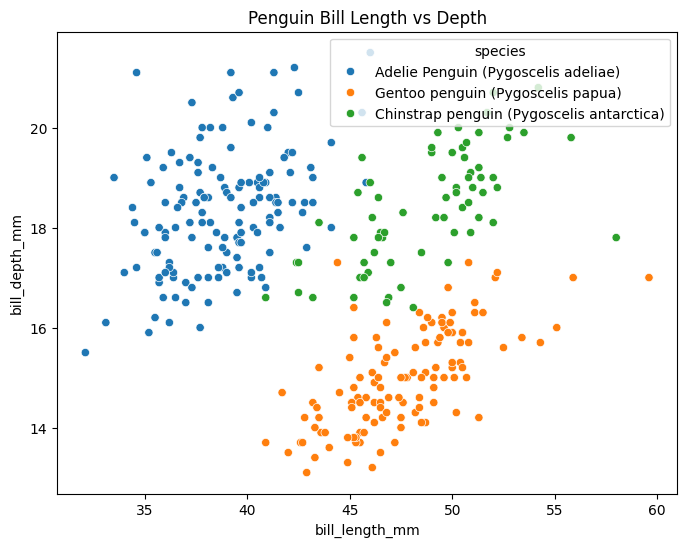

In [15]:
# Quick data visualization
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=penguins_clean,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species"
)

plt.title("Penguin Bill Length vs Depth")
plt.show()

## Clean dataset

In [16]:
penguins_clean.to_csv("E:/Admin/User/Nguyen Thi Phuong Thao/HS Nguyen Thi Phuong Thao/VinUni Academy/B. FALL COURSE 2025/10. Data Visualization/Project 1/data/penguins_clean.csv", index=False)